# ML OOT: stay-not-worse, метрики metrics-ground.md

Сводная `ml_summary.csv` — эксперимент × коридор × горизонт оценки × период. Сигналы зафиксированы (обучение h=5), оценка пересчитана без переобучения.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
summary = pd.read_csv(ROOT / 'reports/tables/ml_summary.csv')
metrics = [
    'lift', 'moment_advantage_bps', 'customer_regret_cvar_95_bps',
    'signals_per_week', 'lift_at_risk', 'cluster_rate',
]
oot = summary[(summary.fold == 'oot') & (summary.evaluation_horizon == 5)]
oot[['experiment', 'corridor', *metrics]].head(10)

,experiment,corridor,lift,moment_advantage_bps,customer_regret_cvar_95_bps,signals_per_week,lift_at_risk,cluster_rate
550,catboost_ab,RUB->AMD,1.262994,-16.483687,269.885404,0.245283,0.772106,0.615385
555,catboost_ab,RUB->KGS,1.388571,-39.100308,510.410697,0.320755,0.852334,0.647059
560,catboost_ab,RUB->KZT,0.733190,-28.683373,332.547555,0.547170,1.192811,0.620690
565,catboost_ab,RUB->TJS,1.902153,-33.068313,420.323577,0.547170,1.005503,0.655172
570,catboost_ab,RUB->UZS,1.317470,-38.412940,492.614329,0.415094,0.976219,0.590909
575,catboost_abcd,RUB->AMD,0.000000,-61.598760,54.785722,0.018868,0.000000,0.000000
580,catboost_abcd,RUB->KGS,1.735714,-8.555078,117.151847,0.075472,6.037950,0.500000
585,catboost_abcd,RUB->KZT,1.012500,-14.146018,62.155043,0.056604,2.293223,0.000000
590,catboost_abcd,RUB->TJS,1.664384,-20.436027,223.875570,0.075472,10.843226,0.500000
595,catboost_abcd,RUB->UZS,1.463855,-31.036728,173.222843,0.075472,4.372558,0.500000


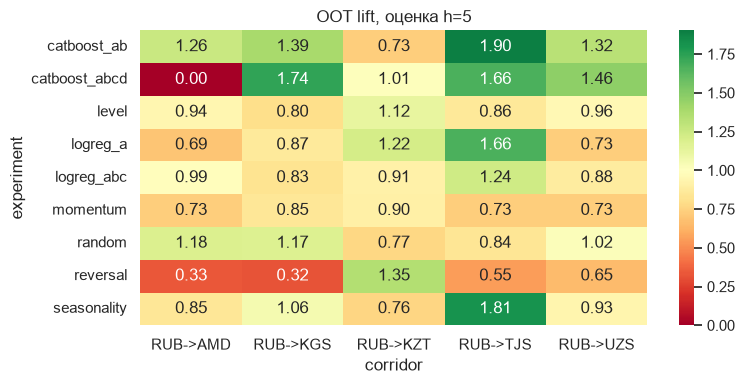

In [2]:
pivot = oot.pivot_table(index='experiment', columns='corridor', values='lift', aggfunc='mean')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0)
plt.title('OOT lift, оценка h=5')
plt.tight_layout()

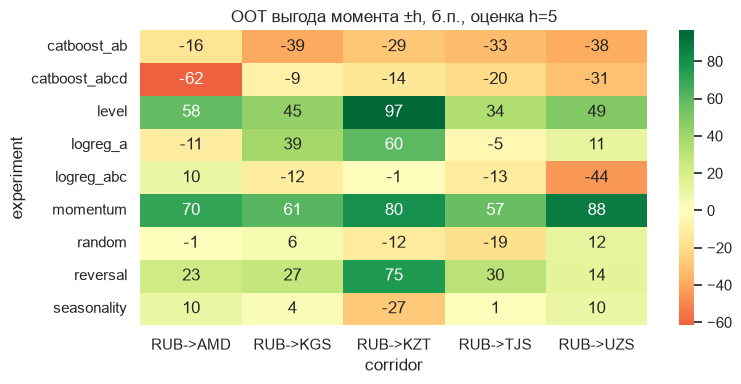

In [3]:
advantage = oot.pivot_table(
    index='experiment', columns='corridor', values='moment_advantage_bps', aggfunc='mean'
)
plt.figure(figsize=(8, 4))
sns.heatmap(advantage, annot=True, fmt='.0f', cmap='RdYlGn', center=0.0)
plt.title('OOT выгода момента ±h, б.п., оценка h=5')
plt.tight_layout()